In [1]:
# Cell 1: LOCO Validation Setup
import os
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

base_dir = "/workspace"
mapped_dir = os.path.join(base_dir, "data/processed/mapped_matrices")
fig_dir = os.path.join(base_dir, "outputs/figures")

# The 20-Gene Panel we are validating
top_20 = ['TTC27', 'CCDC43', 'MPHOSPH10', 'MRPS2', 'EIF2B2', 'LIG4', 'PCSK9', 'ECSIT', 
          'PEX19', 'MRPL22', 'BTN3A2', 'APH1A', 'MYC', 'NOSIP', 'NNMT', 'HMOX1', 
          'ZER1', 'SLC5A9', 'SYMPK', 'NSMAF']

print("[*] Environment Ready. Target: Leave-One-Cohort-Out (LOCO) Validation.")

[*] Environment Ready. Target: Leave-One-Cohort-Out (LOCO) Validation.


In [7]:
# Cell 2: Creating the Air-Gapped Datasets
print("[*] Reading and segregating datasets...")

# All datasets you successfully mapped
all_cohorts = [
    'GSE185263',
    'GSE26440',
    'GSE54514',
    'GSE65682',
    'GSE95233',
    'GSE236713',
    'GSE272769',
    'GSE69063'
]

# Load labels
y_master = pd.read_csv(
    os.path.join(base_dir, "data/processed/ml_tensors/y_master.csv")
)

# Load metadata (contains true Patient_ID)
meta_master = pd.read_csv(
    os.path.join(base_dir, "data/processed/ml_tensors/meta_master.csv")
)

# Ensure consistent formatting
meta_master["Patient_ID"] = (
    meta_master["Patient_ID"]
    .astype(str)
    .str.strip()
)

# Build correct label dictionary
print(f"[*] Reconstructing labels for {len(meta_master)} patients...")

label_dict = dict(
    zip(meta_master["Patient_ID"], y_master["Mortality"])
)

train_dfs = []
test_df = None

for cohort in all_cohorts:

    file_path = os.path.join(
        mapped_dir,
        f"{cohort}_mapped.csv.gz"
    )

    if os.path.exists(file_path):

        # Patients become rows
        df = pd.read_csv(
            file_path,
            index_col=0
        ).T

        # Normalize IDs
        df.index = (
            df.index
            .astype(str)
            .str.strip()
        )

        df.index.name = "Sample_ID"

        # Inject labels
        df["Mortality"] = df.index.map(label_dict)

        # Drop patients without labels
        df = df.dropna(subset=["Mortality"])

        # Keep only selected genes
        cols_to_keep = [
            col for col in top_20
            if col in df.columns
        ] + ["Mortality"]

        df = df[cols_to_keep]

        # Handle missing genes across platforms
        for gene in top_20:
            if gene not in df.columns:
                df[gene] = 0.0

        # Enforce identical column order
        df = df[top_20 + ["Mortality"]]

        if cohort == "GSE65682":

            test_df = df

            print(
                f" -> [HELD OUT] {cohort} "
                f"(N={len(df)}) locked in the vault."
            )

        else:

            train_dfs.append(df)

            print(
                f" -> [TRAIN] Added {cohort} "
                f"(N={len(df)}) to training pool."
            )

# Combine training datasets
train_master = pd.concat(train_dfs, axis=0)

X_train = train_master[top_20]
y_train = train_master["Mortality"]

X_test = test_df[top_20]
y_test = test_df["Mortality"]

print("\n[*] Final Split:")
print(f"    Training Patients: {len(X_train)}")
print(f"    Unseen Test Patients (GSE65682): {len(X_test)}")

[*] Reading and segregating datasets...
[*] Reconstructing labels for 1819 patients...
 -> [TRAIN] Added GSE185263 (N=345) to training pool.
 -> [TRAIN] Added GSE26440 (N=116) to training pool.
 -> [TRAIN] Added GSE54514 (N=127) to training pool.
 -> [HELD OUT] GSE65682 (N=479) locked in the vault.
 -> [TRAIN] Added GSE95233 (N=102) to training pool.
 -> [TRAIN] Added GSE236713 (N=447) to training pool.
 -> [TRAIN] Added GSE272769 (N=161) to training pool.
 -> [TRAIN] Added GSE69063 (N=42) to training pool.

[*] Final Split:
    Training Patients: 1340
    Unseen Test Patients (GSE65682): 479



--- LOCO MODEL TRAINING ---
[*] Training model strictly on non-GSE65682 data...

--- EXTERNAL VALIDATION INFERENCE ---
-> Target ROC-AUC Threshold:  > 0.6000
-> GSE65682 Holdout ROC-AUC:  0.6638


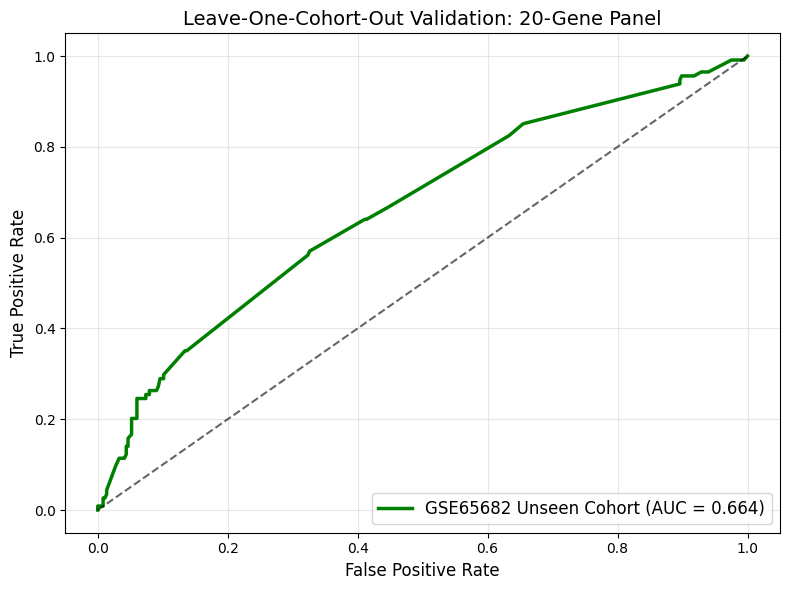

In [8]:
# Cell 3: Training and Validation
print("\n--- LOCO MODEL TRAINING ---")

# Standardize to handle batch effects between the training mix and the test set
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Calculate class imbalance for training
scale_weight = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-9)

loco_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.01, max_depth=4,
    scale_pos_weight=scale_weight, eval_metric='auc', random_state=42, n_jobs=-1
)

print("[*] Training model strictly on non-GSE65682 data...")
loco_model.fit(X_train_scaled, y_train)

print("\n--- EXTERNAL VALIDATION INFERENCE ---")
# Predict on the Air-Gapped GSE65682 cohort
probs_loco = loco_model.predict_proba(X_test_scaled)[:, 1]
auc_loco = roc_auc_score(y_test, probs_loco)

print(f"-> Target ROC-AUC Threshold:  > 0.6000")
print(f"-> GSE65682 Holdout ROC-AUC:  {auc_loco:.4f}")

# Cell 4: Plotting the Evidence
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, probs_loco)

plt.plot(fpr, tpr, label=f'GSE65682 Unseen Cohort (AUC = {auc_loco:.3f})', color='green', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('Leave-One-Cohort-Out Validation: 20-Gene Panel', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(fig_dir, "loco_external_validation.png"), dpi=300)
plt.show()